### Setting up the environment

First thing to do is creating a fresh conda environment so the package and its dependencies stay isolated from your other projects.

I like to keep all of my helper codes and functions here in https://github.com/pranav-satheesh/cosmo_sim_tools. Clone this directory to your home and follow the instructions in the readme to install the package in to your conda environment.

```bash
git clone https://github.com/pranav-satheesh/cosmo_sim_tools.git
cd cosmo_sim_tools

# create the environment from the provided file (installs deps + the package itself)
conda env create -f environment.yml
conda activate cosmo_sim_tools

# register this environment so it shows up as a Jupyter kernel
python -m ipykernel install --user --name cosmo_sim_tools
```


Now restart Jupyter and, using the **kernel selector at the top-right of the
notebook**, choose the `cosmo_sim_tools` kernel. Everything below runs in that kernel.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# The editable install means we can import this anywhere, no sys.path hacks needed.
import cosmo_sim_tools as cosmosim

# NOTE: importing the top-level package does NOT pull in the subpackages,
# so we import the helpers explicitly:
from cosmo_sim_tools.arepo_tools import arepo_package
from cosmo_sim_tools import illustris as il
from cosmo_sim_tools import brahma

## Loading up the Simulation files

### 2. Reading simulation files with `arepo_package`

`output_path` is the directory holding the AREPO outputs for one run — the folder
that contains the `groups_XXX/` (group catalogs) and `snapdir_XXX/` (snapshots)
subfolders. On HiPerGator our runs live under `/orange/lblecha/...`, e.g.:


In [8]:
#The simulation outputs are stored in orange. Let's take a look at one of the BRAHMA simulation data

Brahma_sim_path = '/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/'
#I encourage you to cd in to this directory in your terminal and see all the different runs within this directory. Each run has a different seed for the initial conditions, and the seed is encoded in the name of the run. For example, the run 'L
#All of these are some variations of the simulation with the same box size and particle resolution.
#Let us check one of this
Brahma_sim_name = 'SM5_DFD_3_TNG/'
#Don't worry about the nomenclature for now.
Brahma_sim_file = Brahma_sim_path+Brahma_sim_name

In [9]:
# Which snapshots exist, and what redshift does each correspond to?
snapshots, redshifts = arepo_package.get_snapshot_redshift_correspondence(Brahma_sim_file)
for snap, z in zip(snapshots, redshifts):
    print(f"snapshot {snap:>3d}  ->  z = {z:.3f}")

snapshot   0  ->  z = 25.048
snapshot   1  ->  z = 23.961
snapshot   2  ->  z = 23.032
snapshot   3  ->  z = 22.029
snapshot   4  ->  z = 20.963
snapshot   5  ->  z = 20.046
snapshot   6  ->  z = 18.978
snapshot   7  ->  z = 17.963
snapshot   8  ->  z = 17.000
snapshot   9  ->  z = 16.005
snapshot  10  ->  z = 14.989
snapshot  11  ->  z = 14.034
snapshot  12  ->  z = 13.003
snapshot  13  ->  z = 11.980
snapshot  14  ->  z = 10.976
snapshot  15  ->  z = 9.997
snapshot  16  ->  z = 9.002
snapshot  17  ->  z = 8.012
snapshot  18  ->  z = 7.005
snapshot  19  ->  z = 6.011
snapshot  20  ->  z = 4.996
snapshot  21  ->  z = 4.008
snapshot  22  ->  z = 3.008
snapshot  23  ->  z = 2.002
snapshot  24  ->  z = 1.496
snapshot  25  ->  z = 0.997
snapshot  26  ->  z = 0.700
snapshot  27  ->  z = 0.503
snapshot  28  ->  z = 0.400
snapshot  29  ->  z = 0.298
snapshot  30  ->  z = 0.197
snapshot  31  ->  z = 0.099
snapshot  32  ->  z = 0.000


In [15]:
# grab a valid snapshot number
snap = snapshots[0]

# read everything straight from the BRAHMA group-catalog header
header  = brahma.groupcat.loadHeader(Brahma_sim_file, snap)
om0     = header['Omega0']
oml     = header['OmegaLambda']
h       = header['HubbleParam']
boxsize = header['BoxSize']

print(f"Omega_m={om0}, Omega_L={oml}, h={h}, boxsize={boxsize}")

Omega_m=0.3089, Omega_L=0.6911, h=0.6771, boxsize=12500.0


There are three functions in arepo_package used to load the data from brahma sims. **Each returns a tuple `(data, output_redshift)`**,
where `output_redshift` is the actual redshift of the snapshot it read (the closest one
to what you asked for):

| Function | Reads | Example fields |
|---|---|---|
| `get_group_property`    | FoF halos (groups)   | `Group_M_Crit200`, `GroupPos`, `GroupFirstSub` |
| `get_subhalo_property`  | SUBFIND subhalos     | `SubhaloMassType`, `SubhaloPos`, `SubhaloVel` |
| `get_particle_property` | raw particles        | `Coordinates`, `Masses`, `BH_Mass` |

For particles you also pass a **particle type** `p_type`:

`0` = gas  ·  `1` = dark matter  ·  `4` = stars  ·  `5` = black holes.

Read more about what these quanitites mean in IllustrisTNG documentation

In [36]:
desired_redshift = 5.0
#Let us check the group catalog (halos), subhalo catalog (Subhalos, galaxies) and the particles in this redshift.

# --- Group (halo) catalog ---
halo_masses, z = arepo_package.get_group_property(Brahma_sim_file, "GroupMass", desired_redshift)
print(f"number of FoF groups or halos: {len(halo_masses)}, at z ={z:.3f}")

# --- Subhalo catalog ---
subhalo_masstype, z = arepo_package.get_subhalo_property(Brahma_sim_file, "SubhaloMassType", desired_redshift)

#TO-DO: Check the shape of subhalo_masstype. What do you see? What does it stand for? 
#Check the TNG documentation for help:  https://www.tng-project.org/data/docs/specifications/#sec2a

# --- Particles (note the p_type argument) ---
gas_coords, z = arepo_package.get_particle_property(Brahma_sim_file, "Coordinates", 0, desired_redshift)  # gas
bh_mass,    z = arepo_package.get_particle_property(Brahma_sim_file, "BH_Mass",     5, desired_redshift)  # black holes
print(f"number of black holes : {len(bh_mass)}, at z ={z:.3f}")


number of FoF groups or halos: 119441, at z =4.996
Desired redshift:  5.0
Output redshift:  4.995933468164624
Output snapshot:  20
Desired redshift:  5.0
Output redshift:  4.995933468164624
Output snapshot:  20
number of black holes : 20156, at z =4.996


In [40]:
z

4.995933468164624

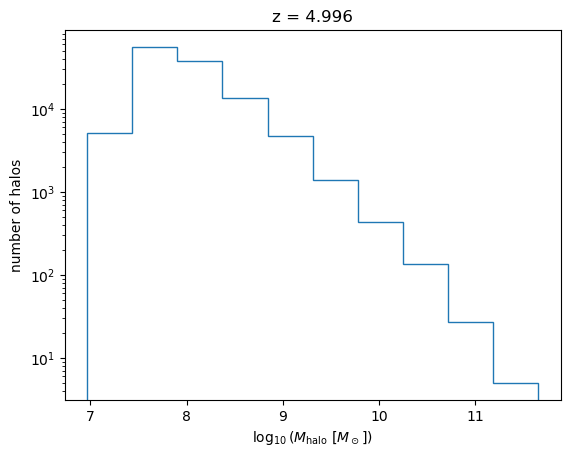

In [48]:
# Let us plot the Halo mass function: distribution of FoF halo masses (units: 1e10 Msun/h)
hmf = halo_masses * 1e10/h
plt.hist(np.log10(hmf[hmf > 0]), bins=10,histtype='step')
plt.xlabel(r"$\log_{10}(M_{\rm halo}\ [M_\odot])$")
plt.ylabel("number of halos")
plt.yscale('log',base=10)
plt.title(f"z = {z:2.3f}")
plt.show()


In [53]:
snap = 2  # the specific snapshot you want to inspect

# per-type particle counts for every subhalo in this snapshot  ->  shape [N_subhalos, 6]
subhalo_lentype = brahma.groupcat.loadSubhalos(Brahma_sim_file, snap, fields="SubhaloLenType")

subhalo_index = 0                        # pick one subhalo
n_bh = subhalo_lentype[subhalo_index][5]  # particle type 5 = black holes

print(f"snapshot {snap}: subhalo {subhalo_index} has {n_bh} black hole(s) ")

snapshot 2: subhalo 0 has 1 black hole(s) 


In [54]:
snap = 20  # the specific snapshot you want to inspect

# per-type particle counts for every subhalo in this snapshot  ->  shape [N_subhalos, 6]
subhalo_lentype = brahma.groupcat.loadSubhalos(Brahma_sim_file, snap, fields="SubhaloLenType")

subhalo_index = 0                        # pick one subhalo
n_bh = subhalo_lentype[subhalo_index][5]  # particle type 5 = black holes

print(f"snapshot {snap}: subhalo {subhalo_index} has {n_bh} black hole(s) ")

snapshot 20: subhalo 0 has 107 black hole(s) 


Woah! That is a huge jump in the number of BHs in these two subhalos. What redshifts are we looking at ? 

In [55]:
# check the redshifts for the above two snapshots.T
#play around with BHs in other subhalos and snapshots

### Number of BHs versus Subhalo Masses

Now, you are set to probe this question. Does larger subhalos produces more number of wandering BHs? How does this vary with redshifts?

#TO-DO:
Pick a redshift and get all the subhalo masses and their respective number of BHs in them. Make a plot of the number of BHs versus the subhalo masses. Change the axes to log-scale if required. Now, try a different redshift, does the interpretation change at different redshifts?